In [2]:
# Import all libraries and dependencies
!pip install graphviz
import pandas as pd

Defaulting to user installation because normal site-packages is not writeable


## Data Preparation

In [3]:
import pandas as pd

# Load the CSV
df = pd.read_csv("BankChurners.csv")

# Drop the 'CLIENTNUM' column
df.drop(columns=['CLIENTNUM'], inplace=True)
df.drop(columns=['Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1'], inplace=True)
df.drop(columns=['Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'], inplace=True)

# Select numeric and categorical columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Print unique values for each categorical column
for col in categorical_cols:
    print(f"Unique values in '{col}':")
    print(df[col].unique())
    print("-" * 50)

Unique values in 'Attrition_Flag':
['Existing Customer' 'Attrited Customer']
--------------------------------------------------
Unique values in 'Gender':
['M' 'F']
--------------------------------------------------
Unique values in 'Education_Level':
['High School' 'Graduate' 'Uneducated' 'Unknown' 'College' 'Post-Graduate'
 'Doctorate']
--------------------------------------------------
Unique values in 'Marital_Status':
['Married' 'Single' 'Unknown' 'Divorced']
--------------------------------------------------
Unique values in 'Income_Category':
['$60K - $80K' 'Less than $40K' '$80K - $120K' '$40K - $60K' '$120K +'
 'Unknown']
--------------------------------------------------
Unique values in 'Card_Category':
['Blue' 'Gold' 'Silver' 'Platinum']
--------------------------------------------------


In [4]:
cleaned_df = df.copy()
# Drop NA
cleaned_df.dropna()
# Drop duplicates
cleaned_df.drop_duplicates(inplace=True)

# IQR Filtering
for col in numeric_cols:
    Q1 = cleaned_df[col].quantile(0.25)
    Q3 = cleaned_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    IQR_cleaned_df = cleaned_df[(cleaned_df[col] >= lower_bound) & (cleaned_df[col] <= upper_bound)]

# Step 4: Check final shape after removing outliers
print("Cleaned dataset shape:", cleaned_df.shape)

# Optional: Save cleaned data
cleaned_df.to_csv("IQRcleaned_dataset.csv", index=False)
cleaned_df.head

Cleaned dataset shape: (10127, 20)


<bound method NDFrame.head of           Attrition_Flag  Customer_Age Gender  Dependent_count  \
0      Existing Customer            45      M                3   
1      Existing Customer            49      F                5   
2      Existing Customer            51      M                3   
3      Existing Customer            40      F                4   
4      Existing Customer            40      M                3   
...                  ...           ...    ...              ...   
10122  Existing Customer            50      M                2   
10123  Attrited Customer            41      M                2   
10124  Attrited Customer            44      F                1   
10125  Attrited Customer            30      M                2   
10126  Attrited Customer            43      F                2   

      Education_Level Marital_Status Income_Category Card_Category  \
0         High School        Married     $60K - $80K          Blue   
1            Graduate         Single 

## Finding the Most Relevant Features

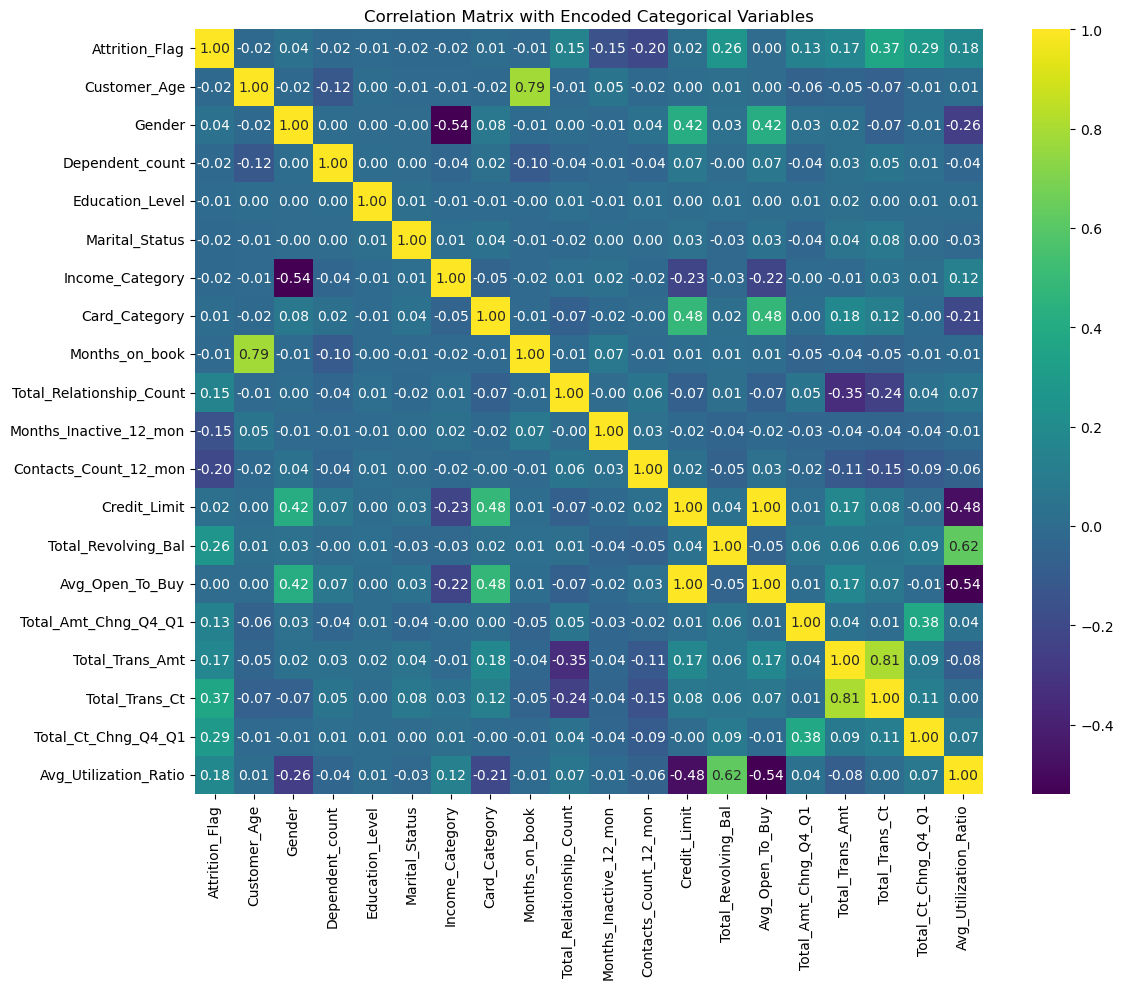

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# List of categorical columns as provided.
categorical_cols = [
    'Attrition_Flag', 
    'Gender', 
    'Education_Level', 
    'Marital_Status', 
    'Income_Category', 
    'Card_Category'
]

# Create a copy of the DataFrame for encoding.
df_encoded = cleaned_df.copy()

# Apply label encoding to each categorical column.
le = LabelEncoder()
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Compute the correlation matrix for the entire DataFrame.
corr_matrix = df_encoded.corr()

# Create a heatmap for the correlation matrix.
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='viridis', annot=True, fmt=".2f")
plt.title('Correlation Matrix with Encoded Categorical Variables')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


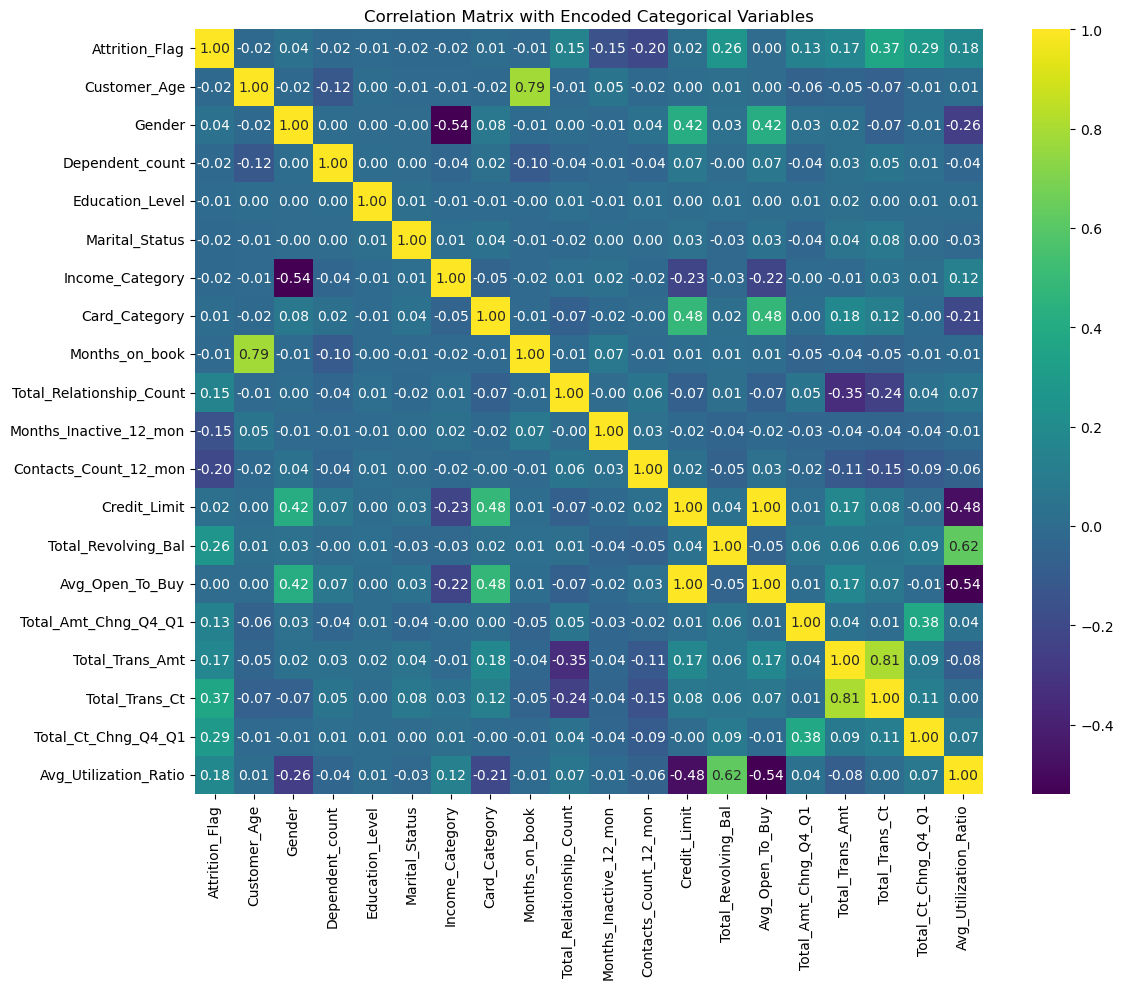

In [50]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# List of categorical columns as provided.
categorical_cols = [
    'Attrition_Flag', 
    'Gender', 
    'Education_Level', 
    'Marital_Status', 
    'Income_Category', 
    'Card_Category'
]

# Create a copy of the DataFrame for encoding.
df_encoded = IQR_cleaned_df.copy()

# Apply label encoding to each categorical column.
le = LabelEncoder()
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Compute the correlation matrix for the entire DataFrame.
corr_matrix = df_encoded.corr()

# Create a heatmap for the correlation matrix.
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='viridis', annot=True, fmt=".2f")
plt.title('Correlation Matrix with Encoded Categorical Variables')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [8]:
import pandas as pd
from sklearn.feature_selection import f_classif

# Assume df_encoded is your DataFrame with all features encoded, including "Attrition_Flag".
# Define the target variable.
target = 'Attrition_Flag'

# Create X containing all features except the target variable,
# and y containing the target.
X = df_encoded.drop(columns=[target])
y = df_encoded[target]

# Compute F-scores and p-values using the ANOVA F-test.
F_values, p_values = f_classif(X, y)

# Create a DataFrame to display the F-scores and p-values along with the feature names.
f_scores_df = pd.DataFrame({
    'Feature': X.columns,
    'F_score': F_values,
    'p_value': p_values
}).sort_values(by='F_score', ascending=False)

print("F-scores against Attrition_Flag:")
print(f_scores_df)


F-scores against Attrition_Flag:
                     Feature      F_score        p_value
16            Total_Trans_Ct  1620.121692   0.000000e+00
17       Total_Ct_Chng_Q4_Q1   930.078416  1.647725e-195
12       Total_Revolving_Bal   752.702408  6.630148e-160
10     Contacts_Count_12_mon   441.868050   4.697490e-96
18     Avg_Utilization_Ratio   332.876795   3.357689e-73
15           Total_Trans_Amt   296.227714   1.857439e-65
9     Months_Inactive_12_mon   240.910376   1.032664e-53
8   Total_Relationship_Count   233.072886   4.829281e-52
14      Total_Amt_Chng_Q4_Q1   176.961638   4.836643e-40
1                     Gender    14.085007   1.757076e-04
11              Credit_Limit     5.773729   1.628536e-02
2            Dependent_count     3.652825   5.600239e-02
4             Marital_Status     3.503085   6.128344e-02
0               Customer_Age     3.356074   6.698689e-02
5            Income_Category     3.131546   7.682098e-02
7             Months_on_book     1.897071   1.684370e-0

In [9]:
import pandas as pd
from sklearn.feature_selection import mutual_info_classif

# Assume df_encoded is your DataFrame with features encoded, including "Attrition_Flag".

# Define the target variable and feature set.
target = 'Attrition_Flag'
X = df_encoded.drop(columns=[target])
y = df_encoded[target]

# Compute the mutual information for each feature with respect to the target.
mi_values = mutual_info_classif(X, y, random_state=42)

# Create a DataFrame to display the mutual information values along with the feature names.
mi_df = pd.DataFrame({
    'Feature': X.columns,
    'Mutual_Information': mi_values
}).sort_values(by='Mutual_Information', ascending=False)

print("Mutual Information of each feature with Attrition_Flag:")
print(mi_df)


Mutual Information of each feature with Attrition_Flag:
                     Feature  Mutual_Information
15           Total_Trans_Amt            0.159579
16            Total_Trans_Ct            0.113819
17       Total_Ct_Chng_Q4_Q1            0.097490
12       Total_Revolving_Bal            0.081312
18     Avg_Utilization_Ratio            0.046084
14      Total_Amt_Chng_Q4_Q1            0.028307
10     Contacts_Count_12_mon            0.023935
13           Avg_Open_To_Buy            0.020645
9     Months_Inactive_12_mon            0.017864
8   Total_Relationship_Count            0.013571
11              Credit_Limit            0.009097
3            Education_Level            0.006701
7             Months_on_book            0.005862
4             Marital_Status            0.005622
2            Dependent_count            0.005081
0               Customer_Age            0.002752
1                     Gender            0.002016
6              Card_Category            0.001135
5            

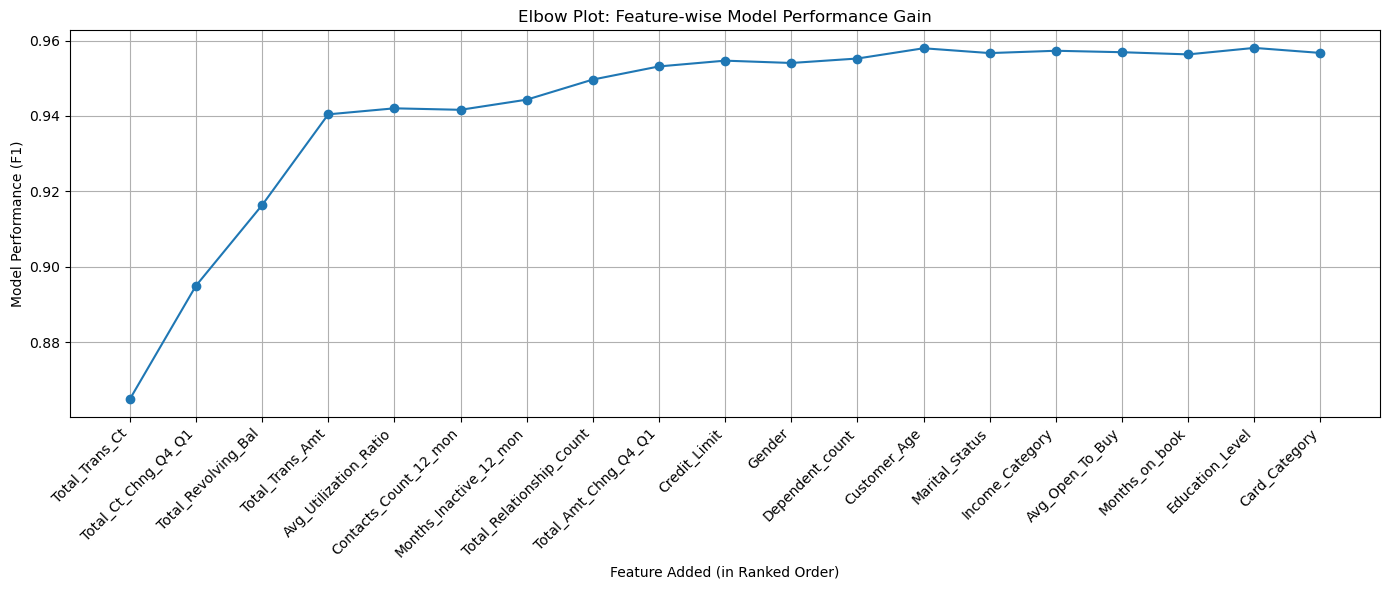

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier  # or LogisticRegression
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# --- Setup ---
# Your DataFrame with encoded categorical columns and target column
df = df_encoded.copy()
y = df['Attrition_Flag']

# Ranked features from previous combined ranking
ranked_features = [
    'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Total_Revolving_Bal', 'Total_Trans_Amt',
    'Avg_Utilization_Ratio', 'Contacts_Count_12_mon', 'Months_Inactive_12_mon',
    'Total_Relationship_Count', 'Total_Amt_Chng_Q4_Q1', 'Credit_Limit', 'Gender',
    'Dependent_count', 'Customer_Age', 'Marital_Status', 'Income_Category',
    'Avg_Open_To_Buy', 'Months_on_book', 'Education_Level', 'Card_Category'
]

# --- Model and scoring ---
model = RandomForestClassifier(random_state=42)
scoring_metric = 'f1'  # or 'accuracy'

# --- Elbow plot prep ---
scores = []
num_features_list = list(range(1, len(ranked_features) + 1))

for i in num_features_list:
    selected_features = ranked_features[:i]
    X = df[selected_features]
    
    # 5-fold cross-validation
    score = cross_val_score(model, X, y, cv=5, scoring=scoring_metric).mean()
    scores.append(score)

# --- Plot ---
# --- Plot ---
plt.figure(figsize=(14, 6))
plt.plot(num_features_list, scores, marker='o')

# Set x-axis labels to the feature name added at each step
added_features = ranked_features  # Already ordered by importance
plt.xticks(ticks=num_features_list, labels=added_features, rotation=45, ha='right')

plt.title('Elbow Plot: Feature-wise Model Performance Gain')
plt.xlabel('Feature Added (in Ranked Order)')
plt.ylabel(f'Model Performance ({scoring_metric.upper()})')
plt.grid(True)
plt.tight_layout()
plt.show()


## Linear Regression

Linear Regression Results:
Coefficient: 0.005810697668566625
Intercept: 0.4624661118338496
Mean Squared Error: 0.1162
R² Score: 0.1379


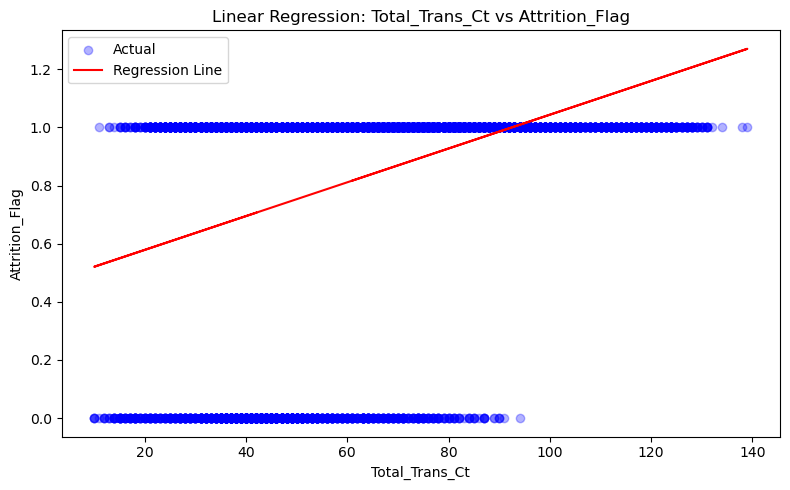

In [11]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Define X and y
X = df_encoded[['Total_Trans_Ct']]
y = df_encoded['Attrition_Flag']

# Fit linear regression
lr = LinearRegression()
lr.fit(X, y)

# Make predictions
y_pred = lr.predict(X)

# Evaluation metrics
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("Linear Regression Results:")
print(f"Coefficient: {lr.coef_[0]}")
print(f"Intercept: {lr.intercept_}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")

# Optional: Visualise the fit
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', alpha=0.3, label='Actual')
plt.plot(X, y_pred, color='red', label='Regression Line')
plt.xlabel('Total_Trans_Ct')
plt.ylabel('Attrition_Flag')
plt.title('Linear Regression: Total_Trans_Ct vs Attrition_Flag')
plt.legend()
plt.tight_layout()
plt.show()

## Logistic Regression

### Logistic Regression: Attrition_Flag against Total_Trans_Ct

Logistic Regression Results:
Coefficient: 0.05432217053505477
Intercept: -1.390949344808464
Accuracy: 0.8334
ROC AUC Score: 0.7956
Confusion Matrix:
[[ 134 1493]
 [ 194 8306]]


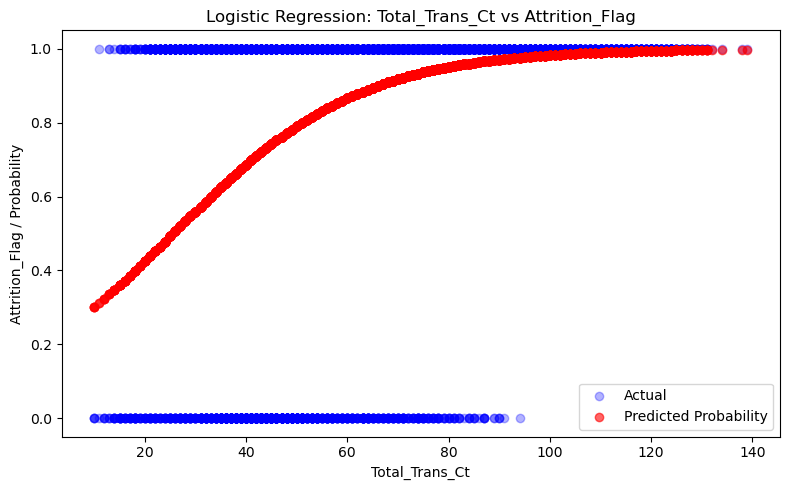

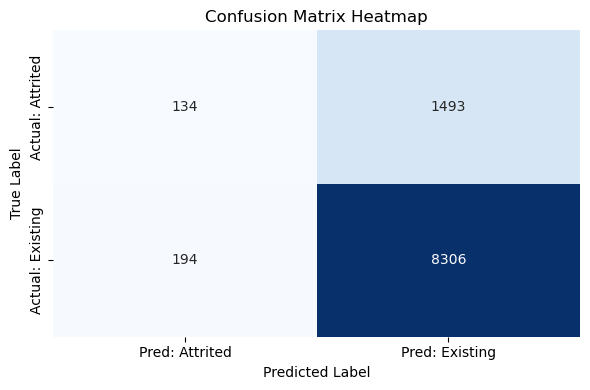

In [12]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Define X and y
X = df_encoded[['Total_Trans_Ct']]
y = df_encoded['Attrition_Flag']

# Fit logistic regression
logreg = LogisticRegression()
logreg.fit(X, y)

# Predict class and probabilities
y_pred_class = logreg.predict(X)
y_pred_proba = logreg.predict_proba(X)[:, 1]  # Probability of class 1 (Attrited)

# Evaluation metrics
acc = accuracy_score(y, y_pred_class)
auc = roc_auc_score(y, y_pred_proba)
cm = confusion_matrix(y, y_pred_class)

print("Logistic Regression Results:")
print(f"Coefficient: {logreg.coef_[0][0]}")
print(f"Intercept: {logreg.intercept_[0]}")
print(f"Accuracy: {acc:.4f}")
print(f"ROC AUC Score: {auc:.4f}")
print("Confusion Matrix:")
print(cm)

# --- Visual: Logistic Regression Curve ---
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', alpha=0.3, label='Actual')
plt.scatter(X, y_pred_proba, color='red', alpha=0.6, label='Predicted Probability')
plt.xlabel('Total_Trans_Ct')
plt.ylabel('Attrition_Flag / Probability')
plt.title('Logistic Regression: Total_Trans_Ct vs Attrition_Flag')
plt.legend()
plt.tight_layout()
plt.show()

# --- Visual: Confusion Matrix Heatmap ---
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred: Attrited', 'Pred: Existing'],
            yticklabels=['Actual: Attrited', 'Actual: Existing'])
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()


### Logistic Regression: Attrition_Flag against Total_Ct_Chng_Q4_Q1

Logistic Regression Results:
Coefficient: 4.965997692835275
Intercept: -1.5473791155267094
Accuracy: 0.8490
ROC AUC Score: 0.7453
Confusion Matrix:
[[ 187 1440]
 [  89 8411]]


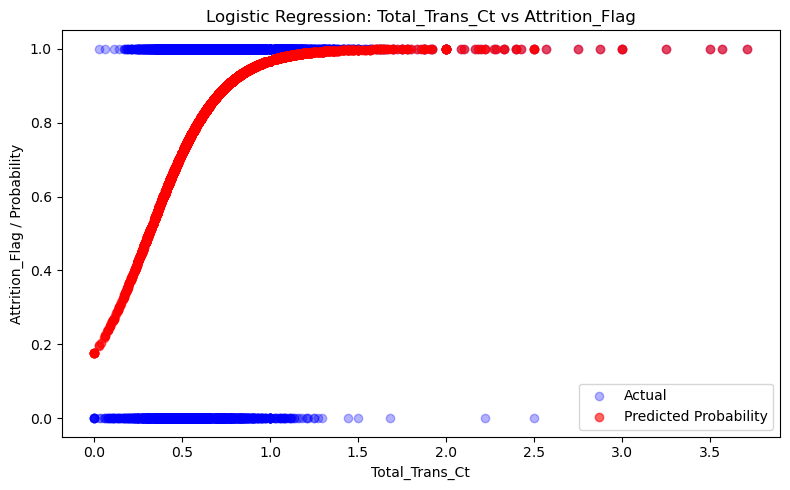

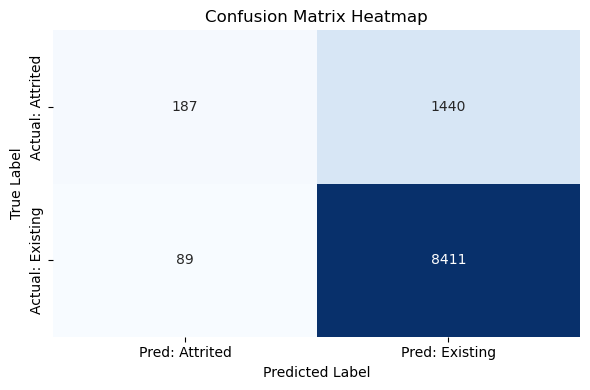

In [13]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Define X and y
X = df_encoded[['Total_Ct_Chng_Q4_Q1']]
y = df_encoded['Attrition_Flag']

# Fit logistic regression
logreg = LogisticRegression()
logreg.fit(X, y)

# Predict class and probabilities
y_pred_class = logreg.predict(X)
y_pred_proba = logreg.predict_proba(X)[:, 1]  # Probability of class 1 (Attrited)

# Evaluation metrics
acc = accuracy_score(y, y_pred_class)
auc = roc_auc_score(y, y_pred_proba)
cm = confusion_matrix(y, y_pred_class)

print("Logistic Regression Results:")
print(f"Coefficient: {logreg.coef_[0][0]}")
print(f"Intercept: {logreg.intercept_[0]}")
print(f"Accuracy: {acc:.4f}")
print(f"ROC AUC Score: {auc:.4f}")
print("Confusion Matrix:")
print(cm)

# --- Visual: Logistic Regression Curve ---
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', alpha=0.3, label='Actual')
plt.scatter(X, y_pred_proba, color='red', alpha=0.6, label='Predicted Probability')
plt.xlabel('Total_Trans_Ct')
plt.ylabel('Attrition_Flag / Probability')
plt.title('Logistic Regression: Total_Trans_Ct vs Attrition_Flag')
plt.legend()
plt.tight_layout()
plt.show()

# --- Visual: Confusion Matrix Heatmap ---
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred: Attrited', 'Pred: Existing'],
            yticklabels=['Actual: Attrited', 'Actual: Existing'])
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()


### Logistic Regression: Attrition_Flag against Total_Revolving_Bal

Logistic Regression Results:
Coefficient: 0.0009275749206390274
Intercept: 0.7633947274499853
Accuracy: 0.8393
ROC AUC Score: 0.6877
Confusion Matrix:
[[   0 1627]
 [   0 8500]]


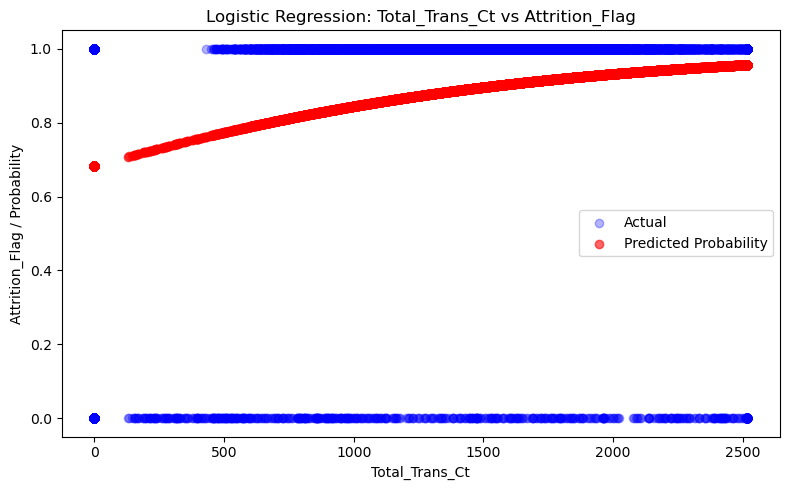

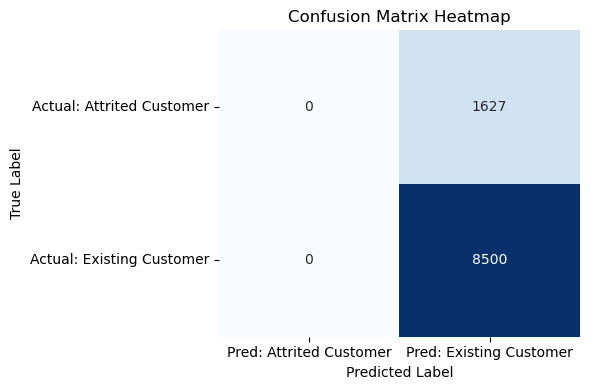

In [14]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Define X and y
X = df_encoded[['Total_Revolving_Bal']]
y = df_encoded['Attrition_Flag']

# Fit logistic regression
logreg = LogisticRegression()
logreg.fit(X, y)

# Predict class and probabilities
y_pred_class = logreg.predict(X)
y_pred_proba = logreg.predict_proba(X)[:, 1]  # Probability of class 1 (Attrited)

# Evaluation metrics
acc = accuracy_score(y, y_pred_class)
auc = roc_auc_score(y, y_pred_proba)
cm = confusion_matrix(y, y_pred_class)

print("Logistic Regression Results:")
print(f"Coefficient: {logreg.coef_[0][0]}")
print(f"Intercept: {logreg.intercept_[0]}")
print(f"Accuracy: {acc:.4f}")
print(f"ROC AUC Score: {auc:.4f}")
print("Confusion Matrix:")
print(cm)

# --- Visual: Logistic Regression Curve ---
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', alpha=0.3, label='Actual')
plt.scatter(X, y_pred_proba, color='red', alpha=0.6, label='Predicted Probability')
plt.xlabel('Total_Trans_Ct')
plt.ylabel('Attrition_Flag / Probability')
plt.title('Logistic Regression: Total_Trans_Ct vs Attrition_Flag')
plt.legend()
plt.tight_layout()
plt.show()

# --- Visual: Confusion Matrix Heatmap ---
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred: Attrited Customer', 'Pred: Existing Customer'],
            yticklabels=['Actual: Attrited Customer', 'Actual: Existing Customer'])
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

### Logistic Regression: Attrition_Flag against Total_Trans_Amt

Logistic Regression Results:
Coefficient: 0.00024092367759846647
Intercept: 0.7639090174091374
Accuracy: 0.8393
ROC AUC Score: 0.6759
Confusion Matrix:
[[   0 1627]
 [   0 8500]]


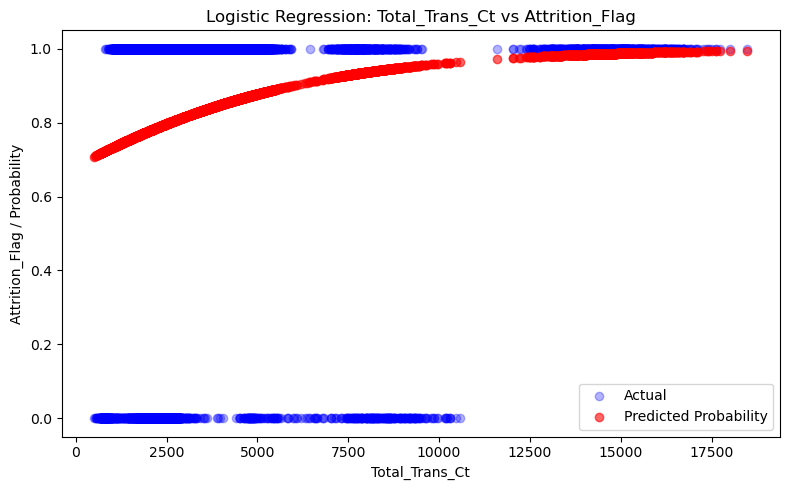

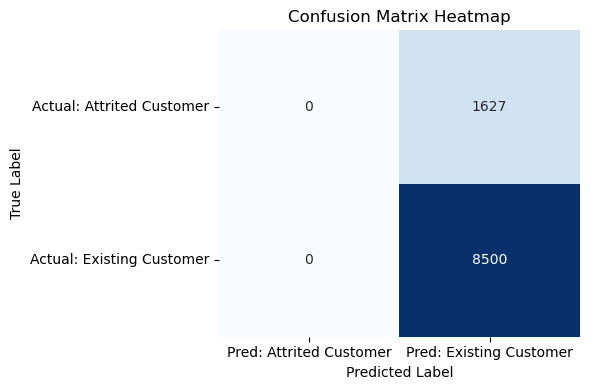

In [15]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Define X and y
X = df_encoded[['Total_Trans_Amt']]
y = df_encoded['Attrition_Flag']

# Fit logistic regression
logreg = LogisticRegression()
logreg.fit(X, y)

# Predict class and probabilities
y_pred_class = logreg.predict(X)
y_pred_proba = logreg.predict_proba(X)[:, 1]  # Probability of class 1 (Attrited)

# Evaluation metrics
acc = accuracy_score(y, y_pred_class)
auc = roc_auc_score(y, y_pred_proba)
cm = confusion_matrix(y, y_pred_class)

print("Logistic Regression Results:")
print(f"Coefficient: {logreg.coef_[0][0]}")
print(f"Intercept: {logreg.intercept_[0]}")
print(f"Accuracy: {acc:.4f}")
print(f"ROC AUC Score: {auc:.4f}")
print("Confusion Matrix:")
print(cm)

# --- Visual: Logistic Regression Curve ---
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', alpha=0.3, label='Actual')
plt.scatter(X, y_pred_proba, color='red', alpha=0.6, label='Predicted Probability')
plt.xlabel('Total_Trans_Ct')
plt.ylabel('Attrition_Flag / Probability')
plt.title('Logistic Regression: Total_Trans_Ct vs Attrition_Flag')
plt.legend()
plt.tight_layout()
plt.show()

# --- Visual: Confusion Matrix Heatmap ---
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred: Attrited Customer', 'Pred: Existing Customer'],
            yticklabels=['Actual: Attrited Customer', 'Actual: Existing Customer'])
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

### Logistic Regression: Attrition_Flag against df_encoded[['Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Total_Revolving_Bal', 'Total_Trans_Amt']]

In view of the low accuracy and performance of single variables, we decided to use a multivariate feature to predict Attrition_Flag

Logistic Regression Results:
Coefficient for Total_Trans_Ct: 0.1040
Coefficient for Total_Ct_Chng_Q4_Q1: 3.0909
Coefficient for Total_Revolving_Bal: 0.0010
Coefficient for Total_Trans_Amt: -0.0005
Intercept: -5.4061
Accuracy: 0.8851
ROC AUC Score: 0.8938
Confusion Matrix:
[[ 805  822]
 [ 342 8158]]


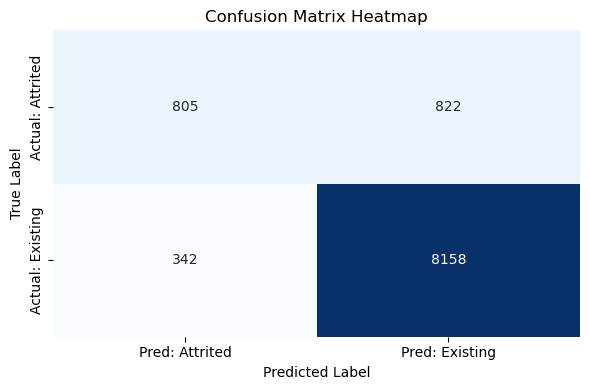

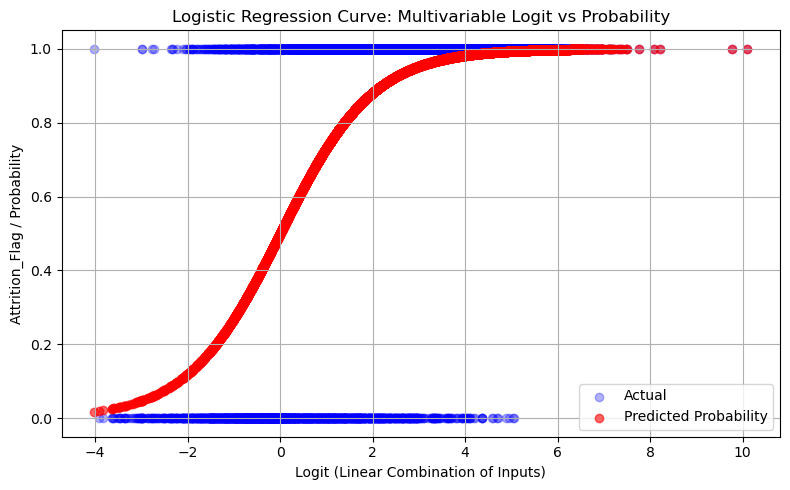

In [16]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Define X and y with 4 top-ranked features
X = df_encoded[['Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Total_Revolving_Bal', 'Total_Trans_Amt']]
y = df_encoded['Attrition_Flag']

# Fit logistic regression
logreg = LogisticRegression(max_iter=1000)  # Increase max_iter for convergence
logreg.fit(X, y)

# Predict class and probabilities
y_pred_class = logreg.predict(X)
y_pred_proba = logreg.predict_proba(X)[:, 1]  # Probability of class 1 (Attrited)

# Evaluation metrics
acc = accuracy_score(y, y_pred_class)
auc = roc_auc_score(y, y_pred_proba)
cm = confusion_matrix(y, y_pred_class)

print("Logistic Regression Results:")
for i, feature in enumerate(X.columns):
    print(f"Coefficient for {feature}: {logreg.coef_[0][i]:.4f}")
print(f"Intercept: {logreg.intercept_[0]:.4f}")
print(f"Accuracy: {acc:.4f}")
print(f"ROC AUC Score: {auc:.4f}")
print("Confusion Matrix:")
print(cm)

# --- Visual: Confusion Matrix Heatmap ---
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred: Attrited', 'Pred: Existing'],
            yticklabels=['Actual: Attrited', 'Actual: Existing'])
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# Compute linear combination (logit) manually
logit_values = np.dot(X, logreg.coef_[0]) + logreg.intercept_[0]

# Plot the sigmoid curve
plt.figure(figsize=(8, 5))
plt.scatter(logit_values, y, color='blue', alpha=0.3, label='Actual')
plt.scatter(logit_values, y_pred_proba, color='red', alpha=0.6, label='Predicted Probability')
plt.xlabel('Logit (Linear Combination of Inputs)')
plt.ylabel('Attrition_Flag / Probability')
plt.title('Logistic Regression Curve: Multivariable Logit vs Probability')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


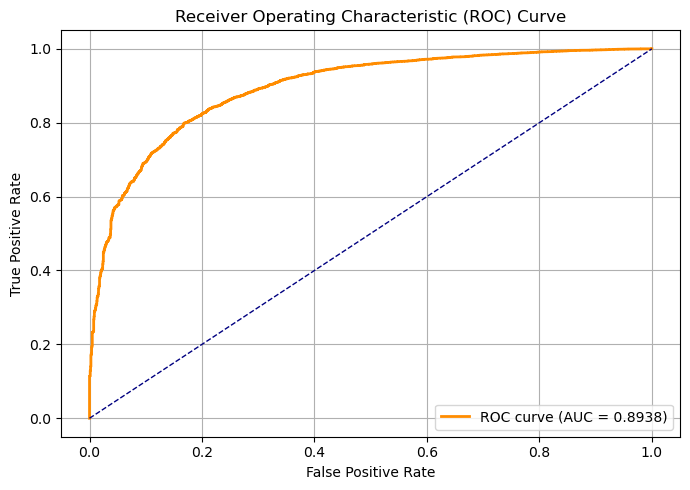

In [17]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


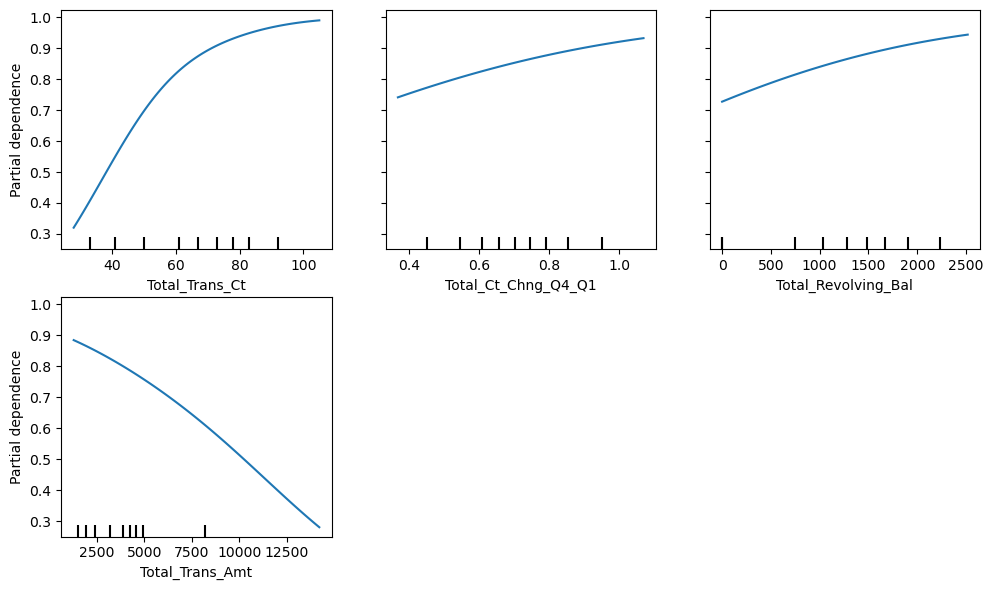

In [18]:
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(figsize=(10, 6))
PartialDependenceDisplay.from_estimator(logreg, X, features=[0, 1, 2, 3], feature_names=X.columns, ax=ax)
plt.tight_layout()
plt.show()


## Decision Trees

Decision Tree Classifier Results:
Accuracy: 0.9275
ROC AUC Score: 0.9476
Confusion Matrix:
[[1247  380]
 [ 354 8146]]


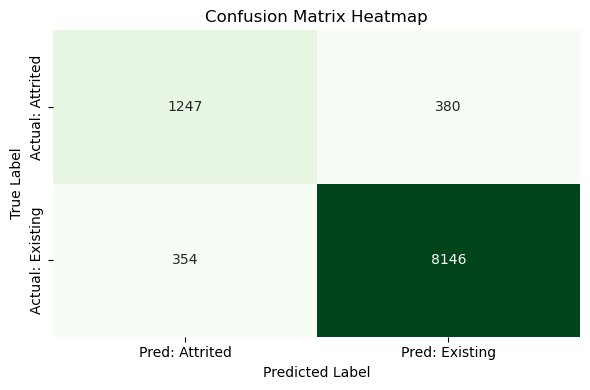

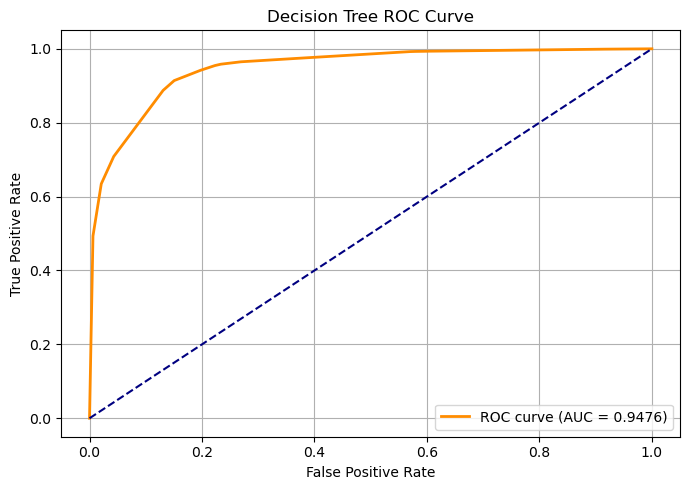

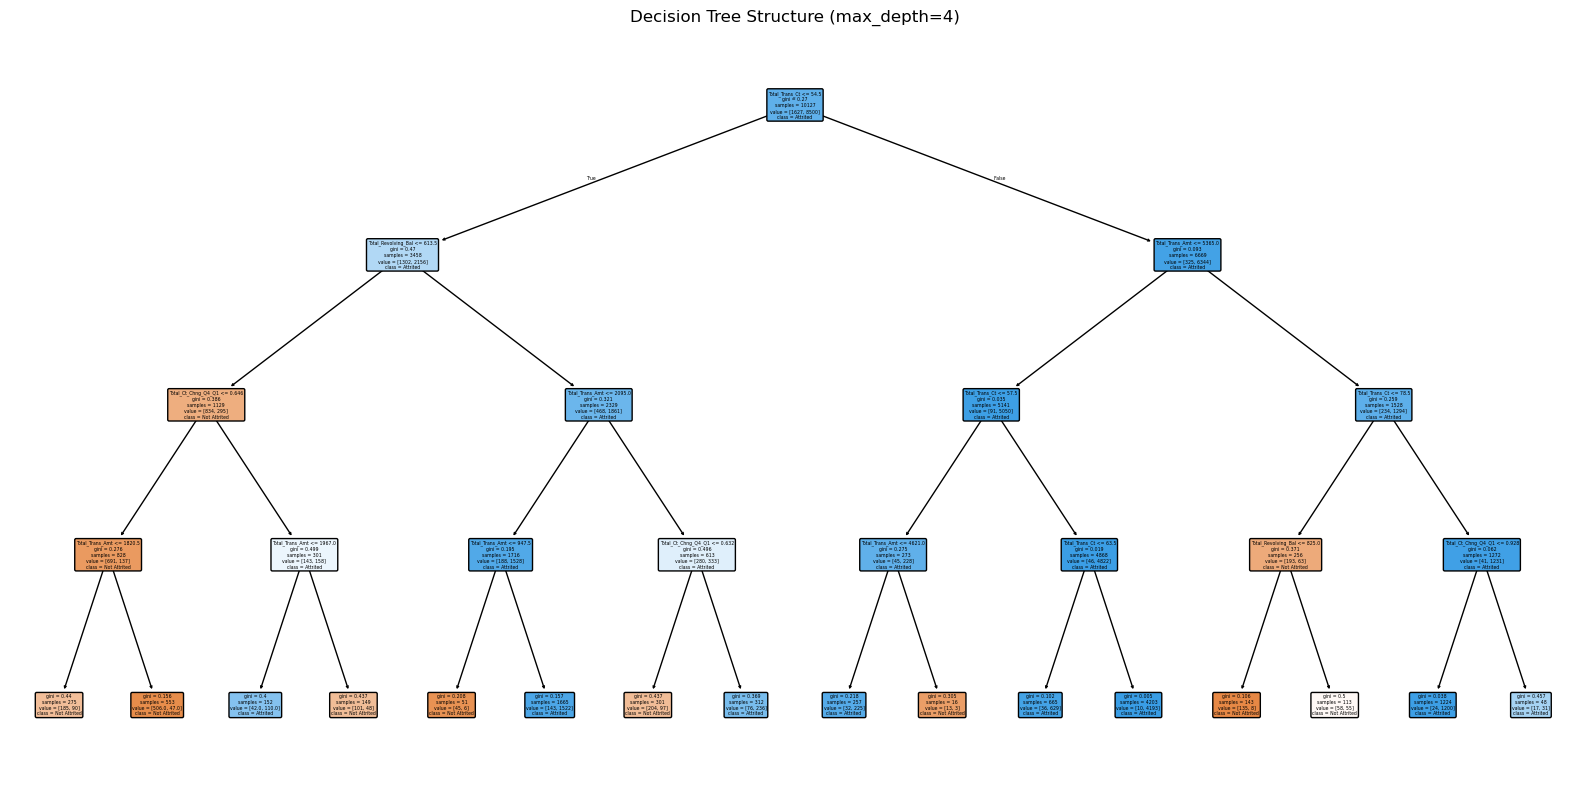

In [19]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Define X and y with top 4 features
X = df_encoded[['Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Total_Revolving_Bal', 'Total_Trans_Amt']]
y = df_encoded['Attrition_Flag']

# Fit Decision Tree Classifier
tree_clf = DecisionTreeClassifier(max_depth=4, random_state=42)  # You can tweak max_depth
tree_clf.fit(X, y)

# Predictions
y_pred_class = tree_clf.predict(X)
y_pred_proba = tree_clf.predict_proba(X)[:, 1]

# Evaluation metrics
acc = accuracy_score(y, y_pred_class)
auc_score = roc_auc_score(y, y_pred_proba)
cm = confusion_matrix(y, y_pred_class)

print("Decision Tree Classifier Results:")
print(f"Accuracy: {acc:.4f}")
print(f"ROC AUC Score: {auc_score:.4f}")
print("Confusion Matrix:")
print(cm)

# --- Visual: Confusion Matrix Heatmap ---
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Pred: Attrited', 'Pred: Existing'],
            yticklabels=['Actual: Attrited', 'Actual: Existing'])
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# --- Visual: ROC Curve ---
fpr, tpr, _ = roc_curve(y, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Decision Tree ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Visual: Decision Tree Structure ---
plt.figure(figsize=(16, 8))
plot_tree(tree_clf, feature_names=X.columns, class_names=['Not Attrited', 'Attrited'],
          filled=True, rounded=True)
plt.title("Decision Tree Structure (max_depth=4)")
plt.tight_layout()
plt.show()


## Random Forest

Random Forest Classifier Results:
Accuracy: 0.9370
ROC AUC Score: 0.9747
Confusion Matrix:
[[1176  451]
 [ 187 8313]]


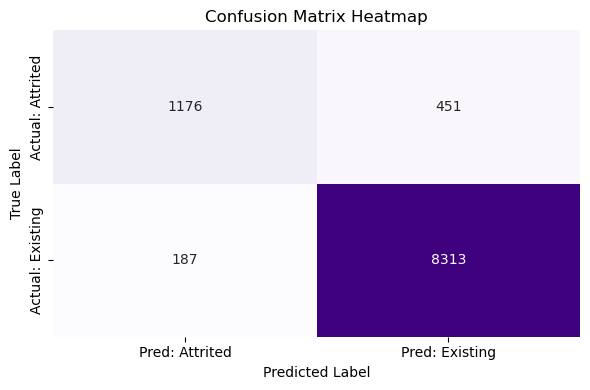

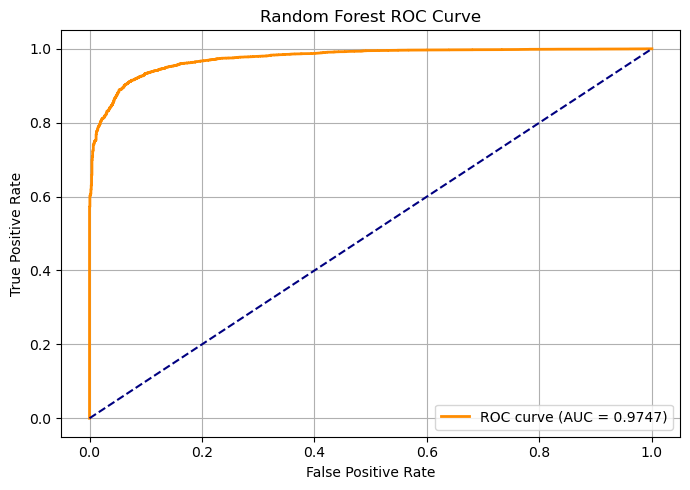

C:\Users\Gan Qing Rong\AppData\Local\Temp\ipykernel_1288\2851421657.py:64: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




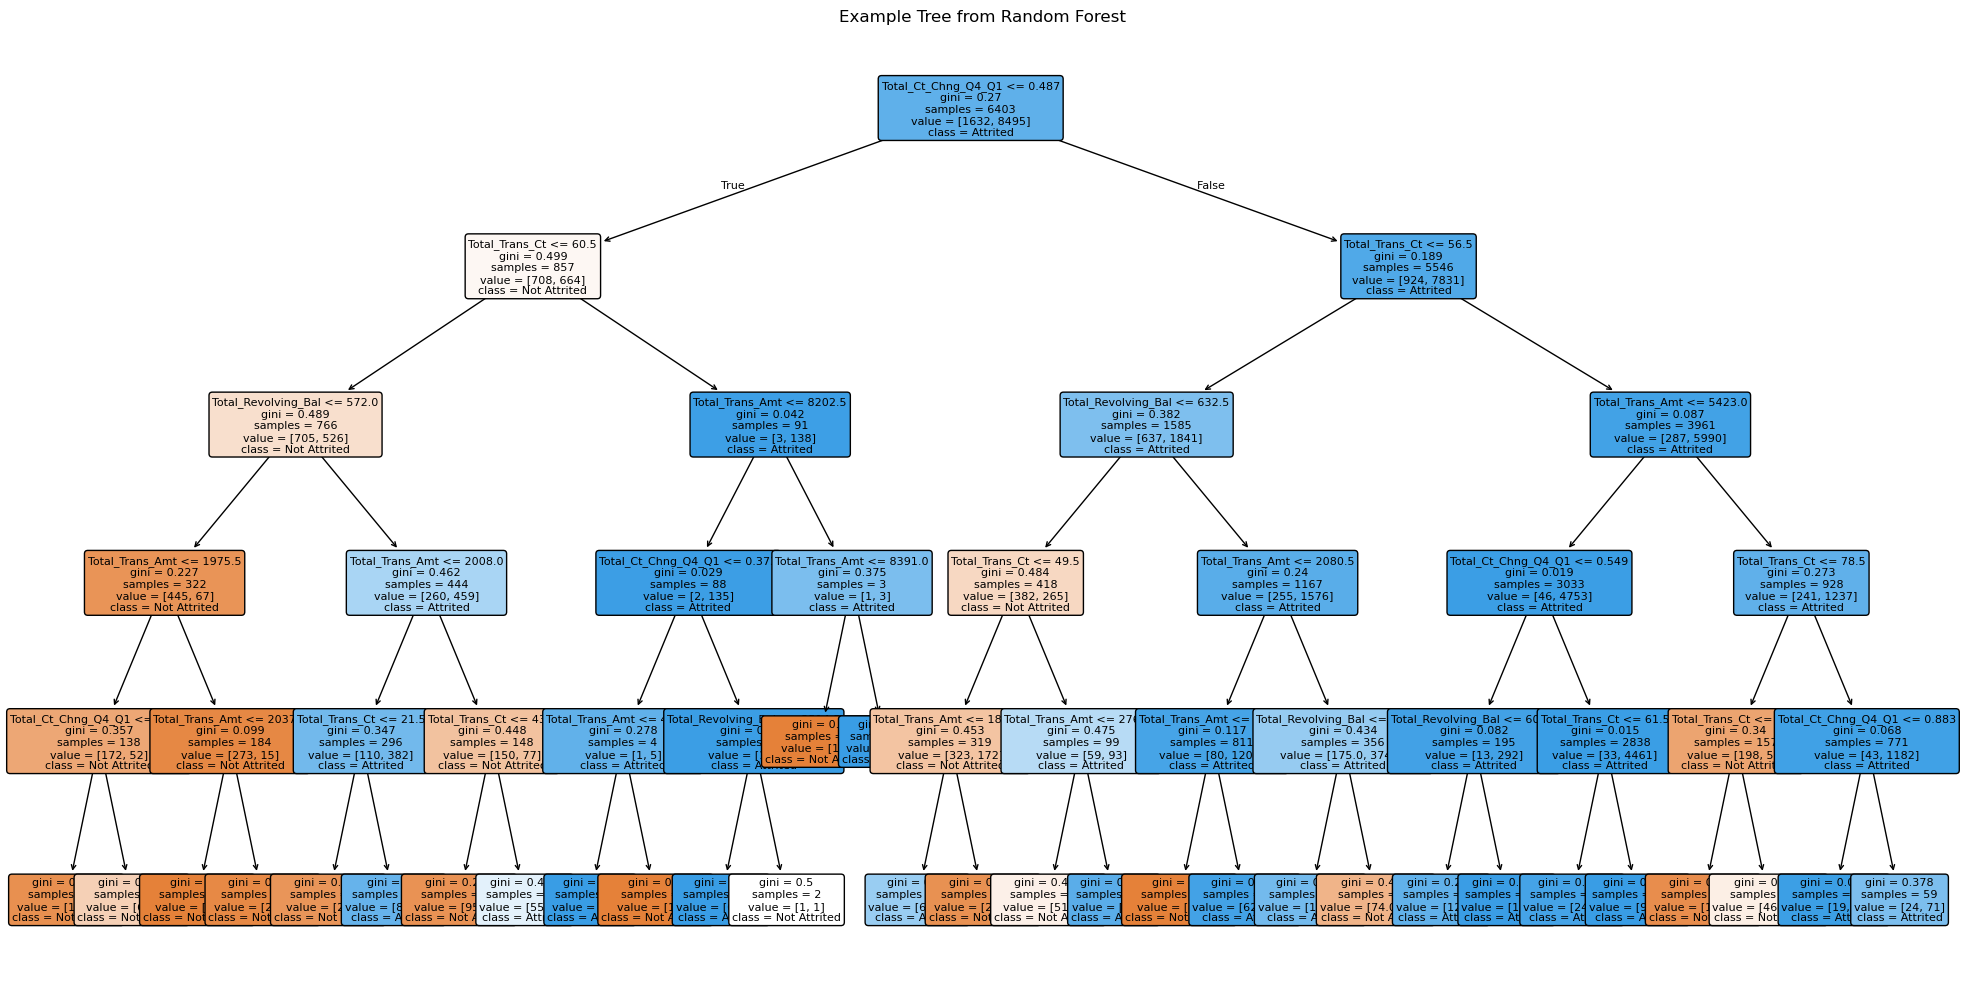

In [36]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, roc_curve, auc
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import seaborn as sns

# Define X and y
X = df_encoded[['Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Total_Revolving_Bal', 'Total_Trans_Amt']]
y = df_encoded['Attrition_Flag']

# Fit Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_clf.fit(X, y)

# Predictions
y_pred_class = rf_clf.predict(X)
y_pred_proba = rf_clf.predict_proba(X)[:, 1]

# Evaluation metrics
acc = accuracy_score(y, y_pred_class)
auc_score = roc_auc_score(y, y_pred_proba)
cm = confusion_matrix(y, y_pred_class)

print("Random Forest Classifier Results:")
print(f"Accuracy: {acc:.4f}")
print(f"ROC AUC Score: {auc_score:.4f}")
print("Confusion Matrix:")
print(cm)

# --- Visual: Confusion Matrix Heatmap ---
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=False,
            xticklabels=['Pred: Attrited', 'Pred: Existing'],
            yticklabels=['Actual: Attrited', 'Actual: Existing'])
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# --- Visual: ROC Curve ---
fpr, tpr, _ = roc_curve(y, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Visual: Feature Importances ---
importances = rf_clf.feature_importances_
features = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(160, 80), dpi=200)
sns.barplot(x=importances[indices], y=features[indices], palette='magma')
plt.title("Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

# --- Visual: One Tree from the Random Forest ---
plt.figure(figsize=(20, 10))
plot_tree(rf_clf.estimators_[0],  # Plot the first tree in the forest
          feature_names=X.columns,
          class_names=['Not Attrited', 'Attrited'],
          filled=True, rounded=True, fontsize=8, )
plt.title("Example Tree from Random Forest")
plt.tight_layout()
plt.show()



## AdaBoost

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoost Classifier Results:
Accuracy: 0.9422
ROC AUC Score: 0.9804
Confusion Matrix:
[[1274  353]
 [ 232 8268]]


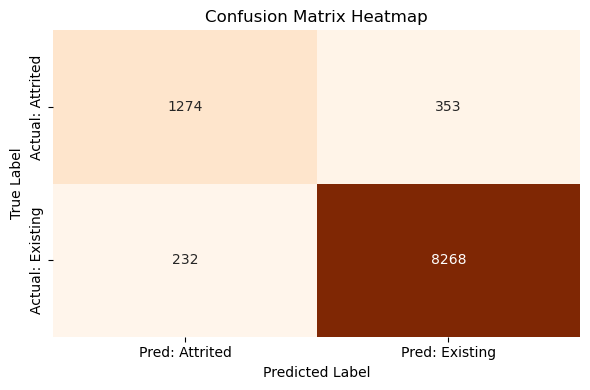

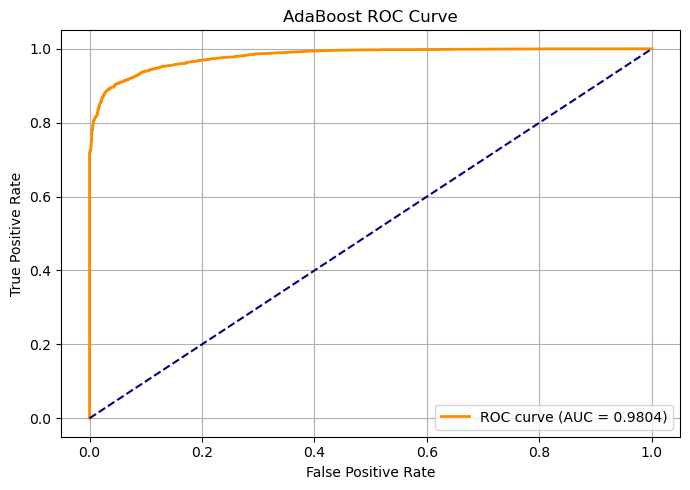

C:\Users\Gan Qing Rong\AppData\Local\Temp\ipykernel_1288\2321007971.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=features[indices], palette='flare')


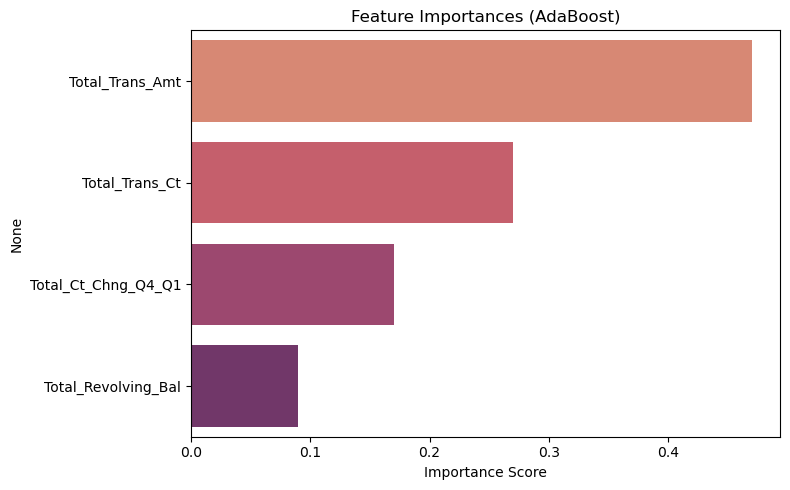

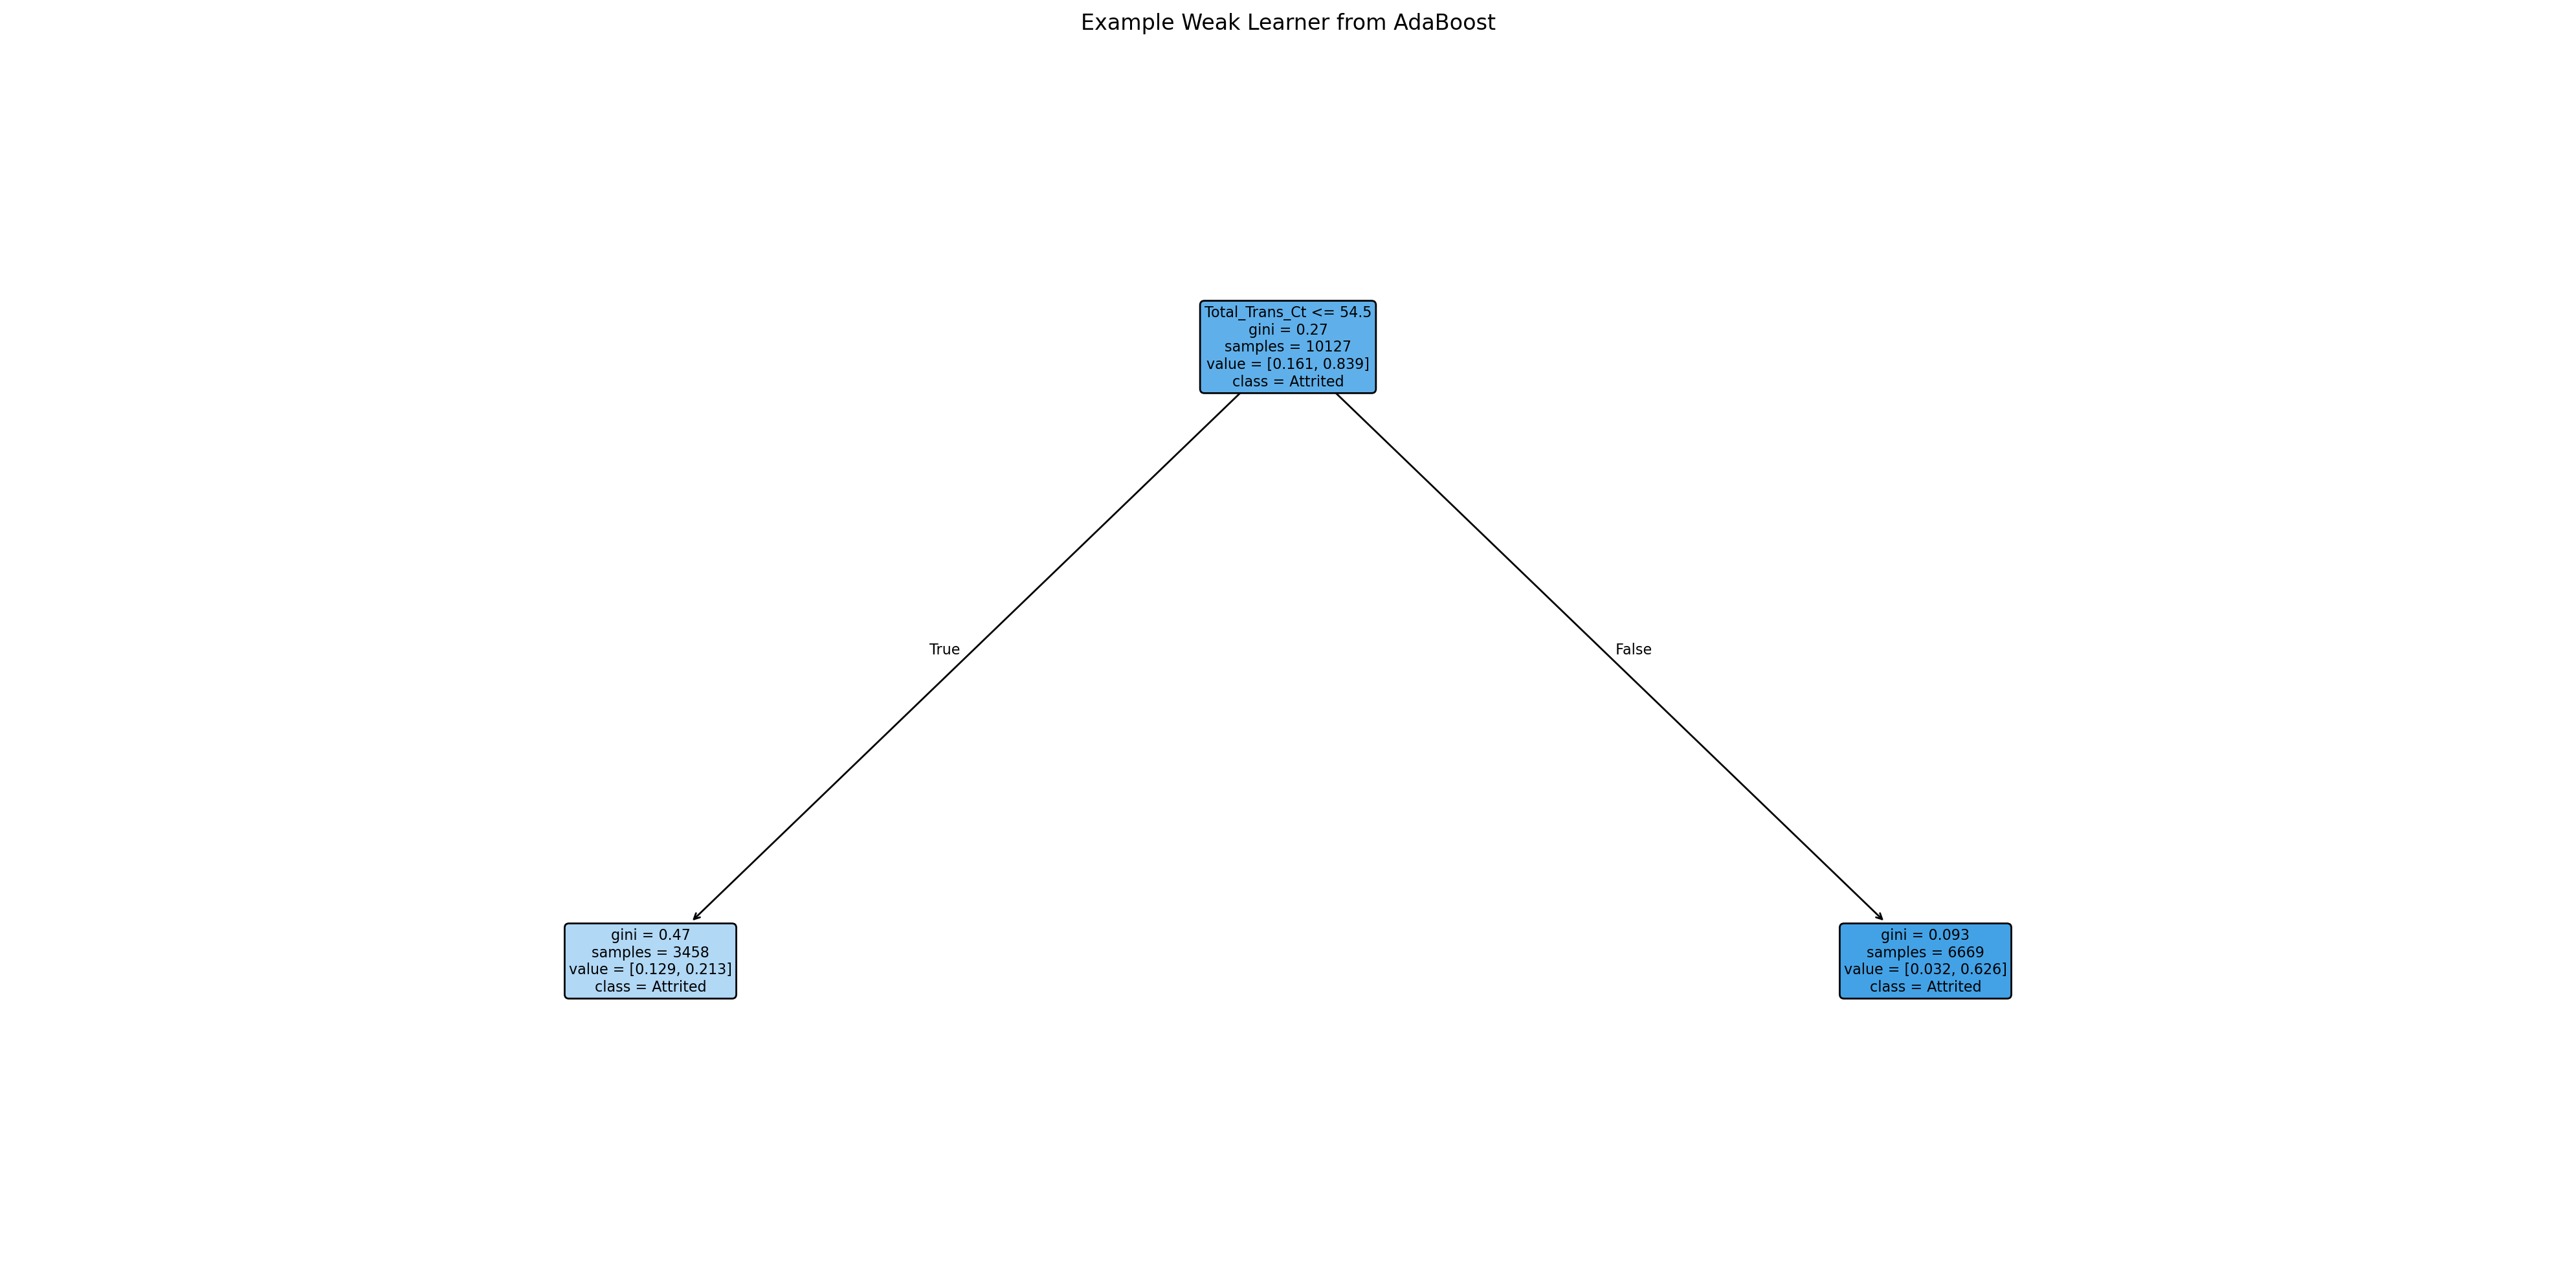

In [21]:
import pandas as pd
import numpy as np
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, roc_curve, auc
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import seaborn as sns

# Define X and y
X = df_encoded[['Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Total_Revolving_Bal', 'Total_Trans_Amt']]
y = df_encoded['Attrition_Flag']

# Fit AdaBoost Classifier
ada_clf = AdaBoostClassifier(n_estimators=100, learning_rate=1.0, random_state=42)
ada_clf.fit(X, y)

# Predictions
y_pred_class = ada_clf.predict(X)
y_pred_proba = ada_clf.predict_proba(X)[:, 1]

# Evaluation metrics
acc = accuracy_score(y, y_pred_class)
auc_score = roc_auc_score(y, y_pred_proba)
cm = confusion_matrix(y, y_pred_class)

print("AdaBoost Classifier Results:")
print(f"Accuracy: {acc:.4f}")
print(f"ROC AUC Score: {auc_score:.4f}")
print("Confusion Matrix:")
print(cm)

# --- Visual: Confusion Matrix Heatmap ---
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Pred: Attrited', 'Pred: Existing'],
            yticklabels=['Actual: Attrited', 'Actual: Existing'])
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# --- Visual: ROC Curve ---
fpr, tpr, _ = roc_curve(y, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AdaBoost ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Visual: Feature Importances ---
importances = ada_clf.feature_importances_
features = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 5))
sns.barplot(x=importances[indices], y=features[indices], palette='flare')
plt.title("Feature Importances (AdaBoost)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

# --- Visual: One Weak Learner Tree (from AdaBoost) ---
# Plot the first decision stump/tree used in AdaBoost
plt.figure(figsize=(20, 10), dpi=200)
plot_tree(ada_clf.estimators_[0],
          feature_names=X.columns,
          class_names=['Not Attrited', 'Attrited'],
          filled=True, rounded=True, fontsize=8)
plt.title("Example Weak Learner from AdaBoost")
plt.tight_layout()
plt.show()


## XGBoost

C:\Users\Gan Qing Rong\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [15:45:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classifier Results:
Accuracy: 0.9489
ROC AUC Score: 0.9823
Confusion Matrix:
[[1284  343]
 [ 174 8326]]


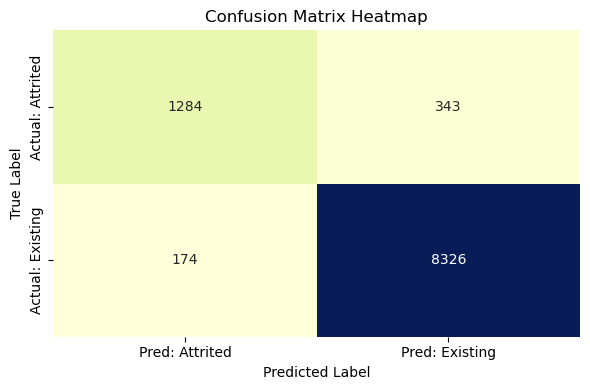

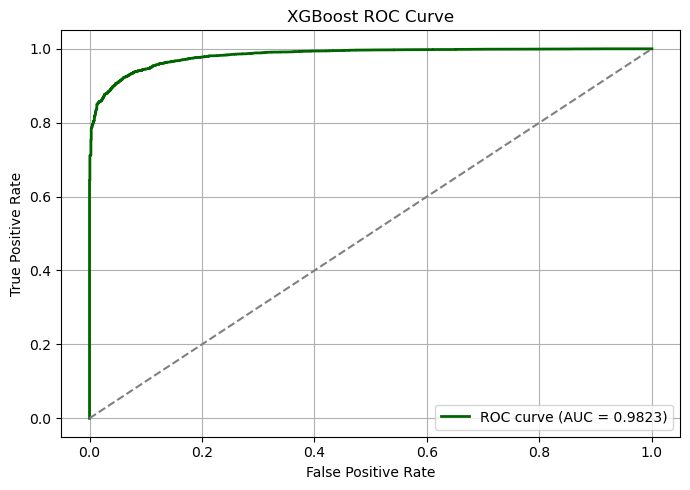

C:\Users\Gan Qing Rong\AppData\Local\Temp\ipykernel_1288\2342401968.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=features[indices], palette='viridis')


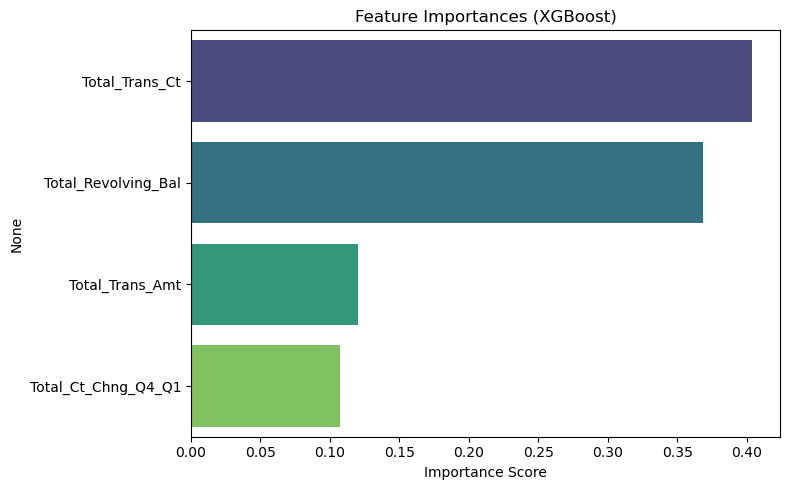

C:\Users\Gan Qing Rong\AppData\Roaming\Python\Python312\site-packages\xgboost\plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

<Figure size 4000x2000 with 0 Axes>

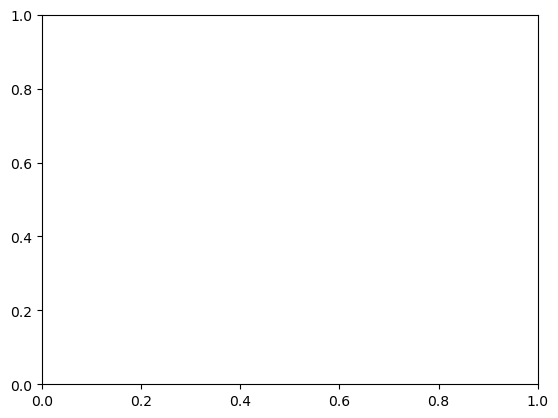

In [22]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier, plot_tree
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Define X and y
X = df_encoded[['Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Total_Revolving_Bal', 'Total_Trans_Amt']]
y = df_encoded['Attrition_Flag']

# Fit XGBoost Classifier
xgb_clf = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_clf.fit(X, y)

# Predictions
y_pred_class = xgb_clf.predict(X)
y_pred_proba = xgb_clf.predict_proba(X)[:, 1]

# Evaluation metrics
acc = accuracy_score(y, y_pred_class)
auc_score = roc_auc_score(y, y_pred_proba)
cm = confusion_matrix(y, y_pred_class)

print("XGBoost Classifier Results:")
print(f"Accuracy: {acc:.4f}")
print(f"ROC AUC Score: {auc_score:.4f}")
print("Confusion Matrix:")
print(cm)

# --- Visual: Confusion Matrix Heatmap ---
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', cbar=False,
            xticklabels=['Pred: Attrited', 'Pred: Existing'],
            yticklabels=['Actual: Attrited', 'Actual: Existing'])
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# --- Visual: ROC Curve ---
fpr, tpr, _ = roc_curve(y, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkgreen', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Visual: Feature Importances ---
importances = xgb_clf.feature_importances_
features = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 5))
sns.barplot(x=importances[indices], y=features[indices], palette='viridis')
plt.title("Feature Importances (XGBoost)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

# --- Visual: Plot a Tree from XGBoost ---
plt.figure(figsize=(20, 10), dpi=200)
plot_tree(xgb_clf, num_trees=0, rankdir='LR')
plt.title("XGBoost - First Tree Visualization")
plt.tight_layout()
plt.show()


## Support Vector Machine (with dimensionality reduction using PCA)

SVM Classifier Results:
Accuracy: 0.9276
ROC AUC Score: 0.9586
Confusion Matrix:
[[1139  488]
 [ 245 8255]]


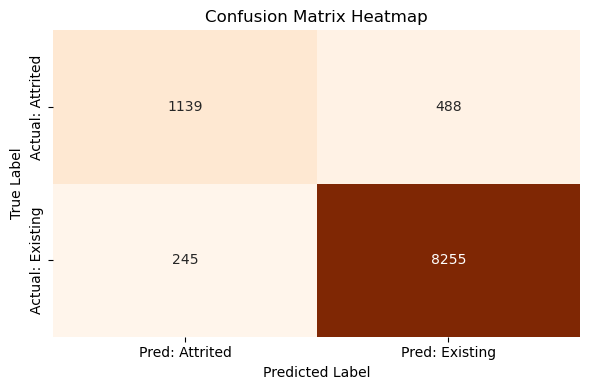

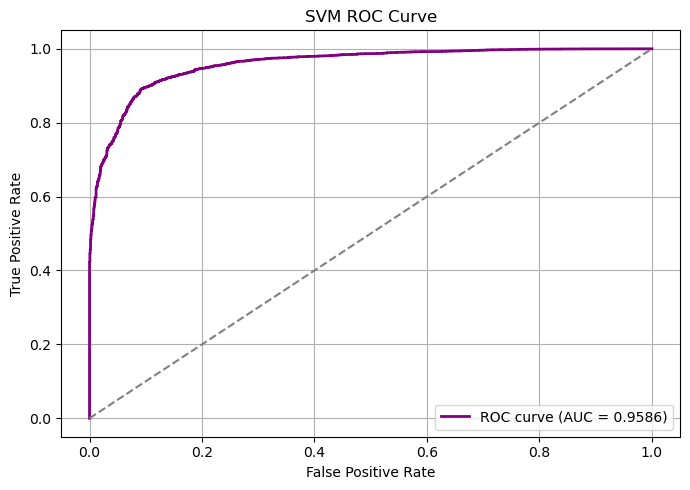

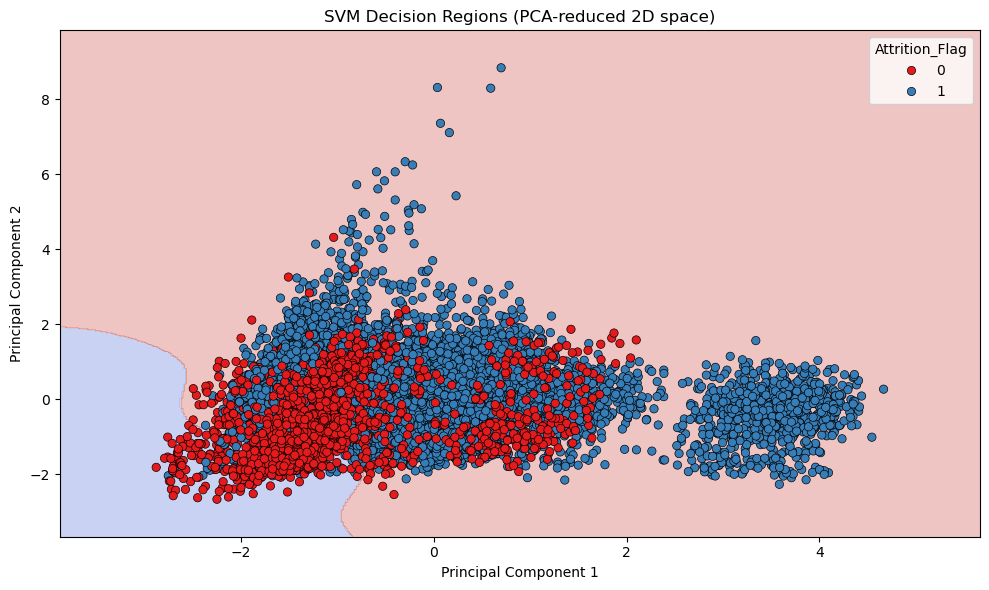

In [53]:
import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, roc_curve, auc
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# --- Define X and y ---
X = df_encoded[['Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Total_Revolving_Bal', 'Total_Trans_Amt']]
y = df_encoded['Attrition_Flag']

# --- Standardize features ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Fit Support Vector Machine ---
svm_clf = SVC(kernel='rbf', probability=True, random_state=42)
svm_clf.fit(X_scaled, y)

# --- Predict ---
y_pred_class = svm_clf.predict(X_scaled)
y_pred_proba = svm_clf.predict_proba(X_scaled)[:, 1]

# --- Evaluation ---
acc = accuracy_score(y, y_pred_class)
auc_score = roc_auc_score(y, y_pred_proba)
cm = confusion_matrix(y, y_pred_class)

print("SVM Classifier Results:")
print(f"Accuracy: {acc:.4f}")
print(f"ROC AUC Score: {auc_score:.4f}")
print("Confusion Matrix:")
print(cm)

# --- Confusion Matrix Heatmap ---
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Pred: Attrited', 'Pred: Existing'],
            yticklabels=['Actual: Attrited', 'Actual: Existing'])
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='purple', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# --- PCA Reduction for 2D Plot ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Refit SVM on PCA space for decision boundary visualization
svm_pca_clf = SVC(kernel='rbf', probability=True)
svm_pca_clf.fit(X_pca, y)

# --- Decision boundary plot in 2D (PCA) ---
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))
Z = svm_pca_clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='Set1', edgecolor='k')
plt.title('SVM Decision Regions (PCA-reduced 2D space)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Attrition_Flag')
plt.tight_layout()
plt.show()


In [54]:
import plotly.graph_objects as go
import numpy as np
import pandas as pd

# Assume svm_clf is already trained on X_scaled (3 features), and you have y_pred
X_3d = pd.DataFrame(X_scaled, columns=['Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Total_Revolving_Bal'])
X_3d['SVM Prediction'] = y_pred
X_3d['Customer Status'] = y.map({0: 'Existing', 1: 'Attrited'})

# Step 1: 3D scatter plot
scatter = go.Scatter3d(
    x=X_3d['Total_Trans_Ct'],
    y=X_3d['Total_Ct_Chng_Q4_Q1'],
    z=X_3d['Total_Revolving_Bal'],
    mode='markers',
    marker=dict(
        size=5,
        color=X_3d['SVM Prediction'],  # 0 = Blue, 1 = Yellow
        colorscale=[[0, 'blue'], [1, 'yellow']],
        opacity=0.7,
        symbol=np.where(X_3d['Customer Status'] == 'Attrited', 'diamond', 'circle')
    ),
    text=X_3d['Customer Status'],
    name='Predicted Class'
)

# Step 2: Red decision plane (from SVM weights)
# Create a mesh grid for plotting the decision surface
x_range = np.linspace(X_3d['Total_Trans_Ct'].min(), X_3d['Total_Trans_Ct'].max(), 10)
y_range = np.linspace(X_3d['Total_Ct_Chng_Q4_Q1'].min(), X_3d['Total_Ct_Chng_Q4_Q1'].max(), 10)
xx, yy = np.meshgrid(x_range, y_range)

# SVM decision plane (based on original 3D features)
coef = svm_clf.coef_[0]
intercept = svm_clf.intercept_[0]
zz = (-coef[0] * xx - coef[1] * yy - intercept) / coef[2]

# Plot the red hyperplane
plane = go.Surface(
    x=xx, y=yy, z=zz,
    showscale=False,
    opacity=0.3,
    colorscale=[[0, 'red'], [1, 'red']],
    name='SVM Hyperplane'
)

# Step 3: Layout
fig = go.Figure(data=[scatter, plane])
fig.update_layout(
    title='SVM Classification in 3D Feature Space<br><sub>Blue: Predicted Existing | Yellow: Predicted Attrited<br>Circle: Actual Existing | Diamond: Actual Attrited</sub>',
    scene=dict(
        xaxis_title='Total_Trans_Ct',
        yaxis_title='Total_Ct_Chng_Q4_Q1',
        zaxis_title='Total_Revolving_Bal'
    ),
    width=1000,
    height=800,
    legend_title_text='Prediction vs Actual',
    margin=dict(l=20, r=20, b=20, t=80)
)

# Save and display
fig.write_html("svm_3d_feature_space_with_hyperplane.html")
fig.show()


ValueError: Shape of passed values is (10127, 4), indices imply (10127, 3)

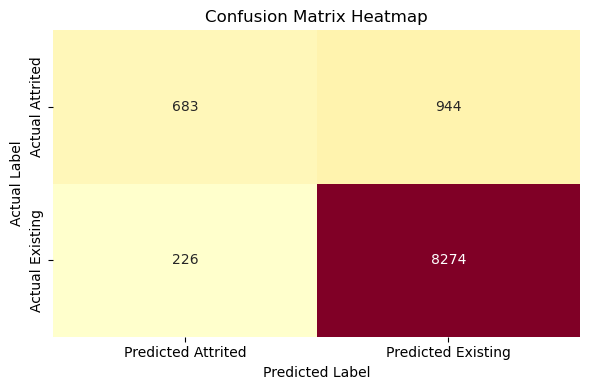

SVM Performance Metrics:
Accuracy : 0.8845
Precision: 0.8976
Recall   : 0.9734
F1 Score : 0.9340


In [48]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# --- Prepare data ---
X_3d = pd.DataFrame(X_scaled, columns=['Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Total_Revolving_Bal'])
X_3d['Actual'] = y.values
X_3d['Predicted'] = y_pred

# --- Classification outcome logic ---
def get_outcome(row):
    if row['Actual'] == 0 and row['Predicted'] == 0:
        return 'True Existing'
    elif row['Actual'] == 1 and row['Predicted'] == 1:
        return 'True Attrited'
    elif row['Actual'] == 1 and row['Predicted'] == 0:
        return 'False Existing'  # Predicted existing, but actually attrited
    else:
        return 'False Attrited'  # Predicted attrited, but actually existing

X_3d['Outcome'] = X_3d.apply(get_outcome, axis=1)

color_map = {
    'True Attrited': 'green',
    'True Existing': 'red',
    'False Attrited': 'yellow',
    'False Existing': 'orange'
}

# --- 3D Scatter Plot ---
scatter = go.Scatter3d(
    x=X_3d['Total_Trans_Ct'],
    y=X_3d['Total_Ct_Chng_Q4_Q1'],
    z=X_3d['Total_Revolving_Bal'],
    mode='markers',
    marker=dict(
        size=5,
        color=[color_map[o] for o in X_3d['Outcome']],
        opacity=0.7
    ),
    text=X_3d['Outcome'],
    name='Classification Outcome'
)

# --- SVM Decision Hyperplane ---
x_range = np.linspace(X_3d['Total_Trans_Ct'].min(), X_3d['Total_Trans_Ct'].max(), 10)
y_range = np.linspace(X_3d['Total_Ct_Chng_Q4_Q1'].min(), X_3d['Total_Ct_Chng_Q4_Q1'].max(), 10)
xx, yy = np.meshgrid(x_range, y_range)
coef = svm_clf.coef_[0]
intercept = svm_clf.intercept_[0]
zz = (-coef[0] * xx - coef[1] * yy - intercept) / coef[2]

plane = go.Surface(
    x=xx, y=yy, z=zz,
    showscale=False,
    opacity=0.3,
    colorscale=[[0, 'red'], [1, 'red']],
    name='SVM Hyperplane'
)

fig = go.Figure(data=[scatter, plane])
fig.update_layout(
    title='SVM Classification Outcome in 3D Feature Space<br><sub>Green: True Attrited | Red: True Existing | Yellow: False Attrited | Orange: False Existing</sub>',
    scene=dict(
        xaxis_title='Total_Trans_Ct',
        yaxis_title='Total_Ct_Chng_Q4_Q1',
        zaxis_title='Total_Revolving_Bal'
    ),
    width=1000,
    height=800,
    legend_title_text='Prediction Outcome',
    margin=dict(l=20, r=20, b=20, t=80)
)
fig.write_html("svm_3d_colored_outcome_with_heatmap.html")
fig.show()

# --- Confusion Matrix Heatmap ---
cm = confusion_matrix(X_3d['Actual'], X_3d['Predicted'])
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='YlOrRd', cbar=False,
    xticklabels=['Predicted Attrited', 'Predicted Existing'],
    yticklabels=['Actual Attrited', 'Actual Existing']
)
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

# --- Evaluation Metrics ---
accuracy = accuracy_score(X_3d['Actual'], X_3d['Predicted'])
precision = precision_score(X_3d['Actual'], X_3d['Predicted'])
recall = recall_score(X_3d['Actual'], X_3d['Predicted'])
f1 = f1_score(X_3d['Actual'], X_3d['Predicted'])

print("SVM Performance Metrics:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")


## K-Means Clustering

We chose 3 features instead for better visualization on 3D plot : 

X = df_encoded[['Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Total_Revolving_Bal']]

Confusion Matrix (KMeans Clusters vs Attrition_Flag):
 [[ 467 1160]
 [5774 2726]]


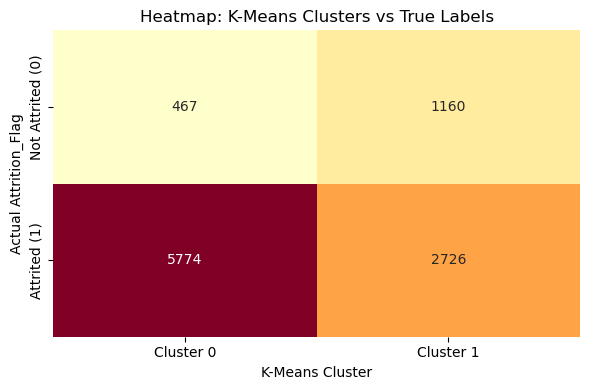

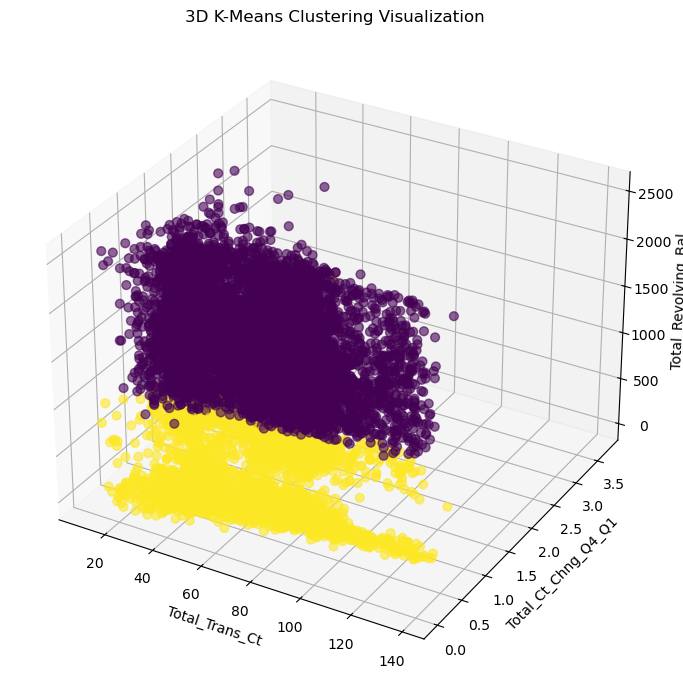

In [24]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Step 1: Select features for clustering
X = df_encoded[['Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Total_Revolving_Bal']]
y = df_encoded['Attrition_Flag']

# Step 2: Run K-Means clustering
kmeans = KMeans(n_clusters=2, random_state=42)
cluster_labels = kmeans.fit_predict(X)

# Step 3: Evaluate cluster-label match (optional for understanding)
cm = confusion_matrix(y, cluster_labels)
print("Confusion Matrix (KMeans Clusters vs Attrition_Flag):\n", cm)

# Step 4: Heatmap of cluster vs label
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', cbar=False,
            xticklabels=['Cluster 0', 'Cluster 1'],
            yticklabels=['Not Attrited (0)', 'Attrited (1)'])
plt.xlabel('K-Means Cluster')
plt.ylabel('Actual Attrition_Flag')
plt.title('Heatmap: K-Means Clusters vs True Labels')
plt.tight_layout()
plt.show()

# Step 5: 3D scatterplot of KMeans clusters
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    X['Total_Trans_Ct'], X['Total_Ct_Chng_Q4_Q1'], X['Total_Revolving_Bal'],
    c=cluster_labels, cmap='viridis', s=40, alpha=0.6
)
ax.set_xlabel('Total_Trans_Ct')
ax.set_ylabel('Total_Ct_Chng_Q4_Q1')
ax.set_zlabel('Total_Revolving_Bal')
ax.set_title('3D K-Means Clustering Visualization')
plt.tight_layout()
plt.show()


In [27]:
import plotly.express as px

# Create a new DataFrame with cluster and actual labels
plot_df = X.copy()
plot_df['KMeans Cluster'] = cluster_labels
plot_df['Customer Status'] = y.map({0: 'Existing', 1: 'Attrited'})  # Rename target values

# Custom color map for cluster labels
cluster_color_map = {0: 'blue', 1: 'gold'}

# Create the interactive 3D plot with larger layout
fig = px.scatter_3d(
    plot_df,
    x='Total_Trans_Ct',
    y='Total_Ct_Chng_Q4_Q1',
    z='Total_Revolving_Bal',
    color='KMeans Cluster',
    symbol='Customer Status',
    opacity=0.7,
    title='K-Means Clustering in 3D (with Actual Attrition Labels)',
    labels={
        'Total_Trans_Ct': 'Total Transactions',
        'Total_Ct_Chng_Q4_Q1': 'CT Change Q4-Q1',
        'Total_Revolving_Bal': 'Revolving Balance',
        'Customer Status': 'Customer Status',
        'KMeans Cluster': 'KMeans Cluster'
    },
    color_discrete_map=cluster_color_map
)

# Expand marker size and layout size for clarity
fig.update_traces(marker=dict(size=6))
fig.update_layout(
    legend_title_text='Legend',
    title_font_size=20,
    scene=dict(
        xaxis_title='Total Transactions',
        yaxis_title='CT Change Q4-Q1',
        zaxis_title='Revolving Balance'
    ),
    width=1000,  # Wider figure
    height=800,  # Taller figure
    margin=dict(l=20, r=20, b=20, t=80)  # Add space for title/labels
)

# Save interactive HTML file
fig.write_html("kmeans_3d_cluster_plot.html")

# Show the plot
fig.show()


## Neural Network (MLPClassifier)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.



Neural Network (MLPClassifier) Results:
Accuracy: 0.9448
ROC AUC Score: 0.9796
F1 Score: 0.9671
Confusion Matrix:
[[1353  274]
 [ 285 8215]]


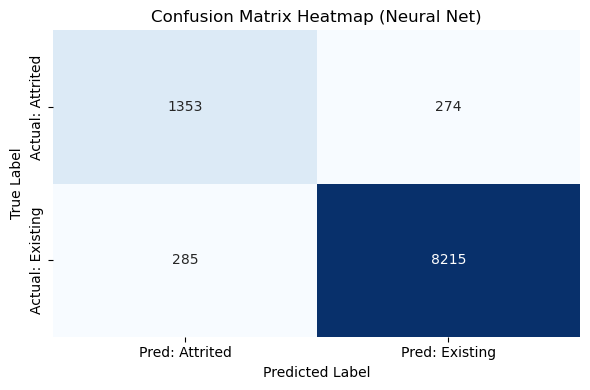

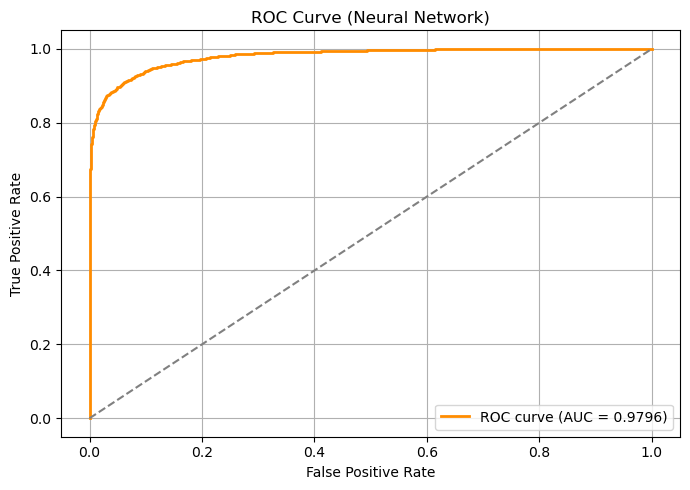

In [49]:
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, roc_curve, auc, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Define X and y
X = df_encoded[['Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Total_Revolving_Bal', 'Total_Trans_Amt']]
y = df_encoded['Attrition_Flag']

# --- Step 1: Standardize features for neural networks ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Step 2: Define and train the neural network ---
mlp = MLPClassifier(hidden_layer_sizes=(16, 8), activation='relu', solver='adam',
                    max_iter=500, random_state=42)
mlp.fit(X_scaled, y)

# --- Step 3: Predictions ---
y_pred_class = mlp.predict(X_scaled)
y_pred_proba = mlp.predict_proba(X_scaled)[:, 1]

# --- Step 4: Evaluation metrics ---
acc = accuracy_score(y, y_pred_class)
auc_score = roc_auc_score(y, y_pred_proba)
f1 = f1_score(y, y_pred_class)
cm = confusion_matrix(y, y_pred_class)

print("Neural Network (MLPClassifier) Results:")
print(f"Accuracy: {acc:.4f}")
print(f"ROC AUC Score: {auc_score:.4f}")
print(f"F1 Score: {f1:.4f}")
print("Confusion Matrix:")
print(cm)

# --- Step 5: Heatmap of Confusion Matrix ---
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred: Attrited', 'Pred: Existing'],
            yticklabels=['Actual: Attrited', 'Actual: Existing'])
plt.title('Confusion Matrix Heatmap (Neural Net)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# --- Step 6: ROC Curve ---
fpr, tpr, _ = roc_curve(y, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Neural Network)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()
